This notebook make the text-classification using pre-trained model and dataset provide by kaggle.
the dataset is describe by text and label, where :
- text  : it's he review of tweet
- label : it's the polarity of review (0 = negative, 1 = positive)

You can find the dataset at [here](https://www.kaggle.com/datasets/hbaflast/french-twitter-sentiment-analysis) on kaggle for more description.

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/users_sentiments_analysis/french_tweets.csv")
data=df.copy()
data.head()

,label,text
0,0,"- Awww, c'est un bummer. Tu devrais avoir davi..."
1,0,Est contrarié qu'il ne puisse pas mettre à jou...
2,0,J'ai plongé plusieurs fois pour la balle. A ré...
3,0,Tout mon corps a des démangeaisons et comme si...
4,0,"Non, il ne se comporte pas du tout. je suis en..."


## Data Analysis

In [ ]:
data.shape

(1526724, 2)

In [ ]:
# duplicated
data.duplicated().sum()

np.int64(51480)

In [ ]:
# drop duplicated
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [ ]:
data.shape

(1475244, 2)

In [ ]:
data.label.unique()

array([0, 1])

<Axes: ylabel='count'>

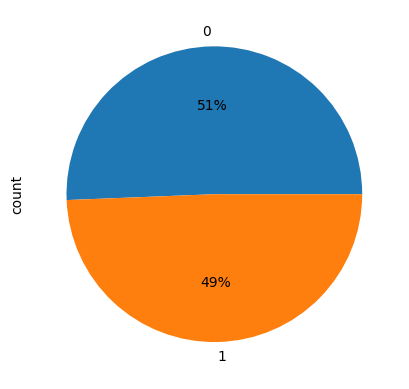

In [ ]:
# display pie diagram of label to see the percent of each label(positive=1 and negative=0)
data.label.value_counts().plot(kind='pie', autopct='%1.0f%%')

You can see that we have 49% of positive label and 51% of negative label.<br>To fixe this problem, we are going to use the stratify k-fold method to avoid the priority of negative label.<br>
Before it we are going to make the préprocessing of data.

## Data Preprocessing
Because we have the important rows count of dataset, we are going to split dataset before to clean it, to reduce the time of cleaning opérations.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1475244 entries, 0 to 1526723
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   label   1475244 non-null  int64 
 1   text    1475244 non-null  object
dtypes: int64(1), object(1)
memory usage: 33.8+ MB


We already have the label as integer , then we can skip the label encoding of labels.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data.text, data.label, test_size=0.2, random_state=0, stratify=data.label)

In [ ]:
# display shape of train and test data
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1180195,), (295049,), (1180195,), (295049,))

In [ ]:
import re
# function to clean dataset
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # remove domain name like thewdb.com
    text = re.sub(r'[a-z]+\.[a-z]+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove newlines
    text = re.sub(r'\n', '', text)
    # Remove alphanumeric words (words containing digits)
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    # Remove remaining non-alphabetic characters (except spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Normalize repeated characters (e.g., "soooo" -> "so")
    text = re.sub(r'(.)\1+', r'\1\1', text)
    return text

In [ ]:
X_train_cleaned=X_train.apply(clean_text)

In [ ]:
X_test_cleaned=X_test.apply(clean_text)

In [ ]:
X_train_cleaned.head()

,text
857146,oui jai tudi un petit peu jai pens que ctait p...
658664,soo yeah long nite
442065,elle est vraiment talentueuse je voulais vraim...
379449,couca boo le spectacle est mardi
223587,jai demand tre un paoft amp ces biatches ne ...


In [ ]:
X_test_cleaned.head()

,text
621609,jai lutt avec ma connexion internet tout le ma...
792863,comment obtenezvous beaucoup je nai eu que co...
1097835,mon grand frre est le meilleur grand frre dans...
175522,dit aujourdhui un triste adieu son petit chie...
889128,bonne journe de mommaa ma mre est la salle ...


We can see that the text of training and testing data had been cleaning very well. <br>
Now we are going to save data, load and train pre-trained model since Hugging Face.

In [ ]:
import joblib

In [ ]:
joblib.dump(X_train_cleaned, '/content/drive/MyDrive/users_sentiments_analysis/X_train_cleaned.data')

['/content/drive/MyDrive/users_sentiments_analysis/X_train_cleaned.data']

In [ ]:
joblib.dump(X_test_cleaned, '/content/drive/MyDrive/users_sentiments_analysis/X_test_cleaned.data')

['/content/drive/MyDrive/users_sentiments_analysis/X_test_cleaned.data']

## Training model on data using Hugging Face Platform
In this case we are going to use a model pre-training on french language.<br>
we can use many populars pre-training models, then we can use :
- Camembert : because it's spécialized on french language
- Flaubert  : it's alos the variant bert model specialized on french language.

### Camembert model

In this section, we will make some actions :
- prepare dataset for model
- tokenize dataset form model
- prepare the compute of metrics for model
- prepare arguments for the train of model
- train model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer,DataCollatorWithPadding

In [ ]:
# load camembert model
camembert_tokenizer=AutoTokenizer.from_pretrained("camembert-base")
camembert_model=AutoModelForSequenceClassification.from_pretrained("camembert-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# 1.prepare dataset
from datasets import Dataset

In [ ]:
# shape before training
X_train_cleaned.shape, y_train.shape, X_test_cleaned.shape, y_test.shape

((1180195,), (1180195,), (295049,), (295049,))

In [ ]:
df_train=pd.concat([X_train_cleaned,y_train],axis=1).sample(n=5000, random_state=0).reset_index(drop=True)
df_test=pd.concat([X_test_cleaned,y_test],axis=1).sample(n=5000, random_state=0).reset_index(drop=True)

In [ ]:
train_dataset=Dataset.from_pandas(df_train)
test_dataset=Dataset.from_pandas(df_test)

In [ ]:
train_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})

In [ ]:
test_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})

In [ ]:
# camembert tokenizer data
def tokenize_with_camembert(batch):
    return camembert_tokenizer(batch["text"], padding=True, truncation=True, max_length=512)


In [ ]:
# 2.Tokenize datasets
train_dataset_tokenized=train_dataset.map(tokenize_with_camembert,batched=True)
test_dataset_tokenized=test_dataset.map(tokenize_with_camembert,batched=True)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [ ]:
# dave dataset tokenized
joblib.dump(train_dataset_tokenized, '/content/drive/MyDrive/users_sentiments_analysis/train_dataset_tokenized.data')
joblib.dump(test_dataset_tokenized, '/content/drive/MyDrive/users_sentiments_analysis/test_dataset_tokenized.data')

['/content/drive/MyDrive/users_sentiments_analysis/test_dataset_tokenized.data']

In [ ]:
# load data collector to ajust padding dynamically
camember_data_collector=DataCollatorWithPadding(tokenizer=camembert_tokenizer)

In [ ]:
#3.Prepare metrics for training model
!pip install evaluate

In [ ]:
import evaluate
metrics=evaluate.load("accuracy")

In [ ]:
# this function will be evaluate metrics during the train of model
import numpy as np
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # get the highest class from logits values
    predictions = np.argmax(logits, axis=-1)
    return metrics.compute(predictions=predictions, references=labels)

In [ ]:
#  prepare arguments for the train of model
training_args=TrainingArguments(
    output_dir="/content/drive/MyDrive/users_sentiments_analysis/results_camembert",
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=50,
    per_device_eval_batch_size=50,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    seed=0,
    use_cpu=True
)

In [ ]:
# train model
trainer=Trainer(
    model=camembert_model,
    args=training_args,
    train_dataset=train_dataset_tokenized,
    eval_dataset=test_dataset_tokenized,
    data_collator=camember_data_collector,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()
trainer.save_model("/content/drive/MyDrive/users_sentiments_analysis/results_camembert")
camembert_tokenizer.save_pretrained("/content/drive/MyDrive/users_sentiments_analysis/results_camembert")

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.526257,0.759400
2,No log,0.504537,0.770600
3,No log,0.510040,0.780600
4,No log,0.522298,0.774000
5,0.458746,0.523950,0.776800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/users_sentiments_analysis/results_camembert/tokenizer_config.json',
 '/content/drive/MyDrive/users_sentiments_analysis/results_camembert/tokenizer.json')

On Observe que notre model atteint son maximum de bonne metrique à la 3ieme époque.<br>
Apres 4H25:04 notre modèle à une performence de 78% sur les données qu'il na jamais vue et une loss de 0.51.<br>
Nous pouvons aussi remarquer une loss faible à la 2ieme époque pour une accuracy de 77% sur les données de validation.<br>
In the next section, we're going to evalute model on new data and display metrics.

#### Evaluation of Camembert model

In [ ]:
# get list of df_test and df_train using to train model
list_test=df_test["text"].tolist()
list_train=df_train["text"].tolist()

In [ ]:
# get all df_test and df_train values
df_train_all=pd.concat([X_train_cleaned,y_train],axis=1).reset_index(drop=True)
df_test_all=pd.concat([X_test_cleaned,y_test],axis=1).reset_index(drop=True)

In [ ]:
# get text and label not using during training of model to evaluate metrics of model
def get_val_set(df,list_data):
  test_set=[]
  for i in df_test.index:
    if(df.iloc[i]["text"] not in list_data) :
      test_set.append([df.iloc[i]["text"],df.iloc[i]["label"]])
  return pd.DataFrame(test_set,columns=["text","label"])

In [ ]:
# filter df_test values
def_val_test=get_val_set(df_test_all,list_test)
def_val_test.shape

(4911, 2)

In [ ]:
# filter df_train values
def_val_train=get_val_set(df_train_all,list_train)
def_val_train.shape

(4977, 2)

In [ ]:
# concat df_val_test and df_val_train that model never seeing
df_val=pd.concat([def_val_train,def_val_test],axis=0).reset_index(drop=True)
df_val.shape

(9888, 2)

In [ ]:
!pip install tqdm

In [ ]:
import torch
from sklearn.metrics import accuracy_score
from tqdm import tqdm

In [ ]:
# evaluate the model trained
# load model trained
chemin_modele = "/content/drive/MyDrive/users_sentiments_analysis/results_camembert"
tokenizer = AutoTokenizer.from_pretrained(chemin_modele)
model = AutoModelForSequenceClassification.from_pretrained(chemin_modele)

# use GPU or cpu computer strategy
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# using df_val
texts = df_val["text"].tolist()
true_labels = df_val["label"].tolist()

# init variable to save model predictions
predictions_labels = []
batch_size = 100

# enable evaluation mode
model.eval()
with torch.no_grad():
    for i in tqdm(range(0, len(texts), batch_size),"in progress"):
        batch_texts = texts[i:i+batch_size]
        # Tokenisation
        inputs = tokenizer(batch_texts, truncation=True, padding=True, max_length=128, return_tensors="pt").to(device)

        # pass inputs tokenized to camembert model trained and get logits values
        outputs = model(**inputs)
        logits = outputs.logits

        # get the max probability for logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        predictions_labels.extend(preds)
# compute accuracy
score_accuracy = accuracy_score(true_labels, predictions_labels)

print(f"--- FINAL RESULTS ---")
print(f"number of texts : {len(texts)}")
print(f"global Accuracy : {score_accuracy * 100:.2f} %")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

in progress: 100%|██████████| 99/99 [21:08<00:00, 12.82s/it]

--- FINAL RESULTS ---
number of texts : 9888
global Accuracy : 76.09 %


we have an accuracy equal to de 76% on the validation set, which is lower than 78% form the high Camembert model.<br>
Now we're going to display the learning rate and classidication métrics.


In [ ]:
import matplotlib.pyplot as plt

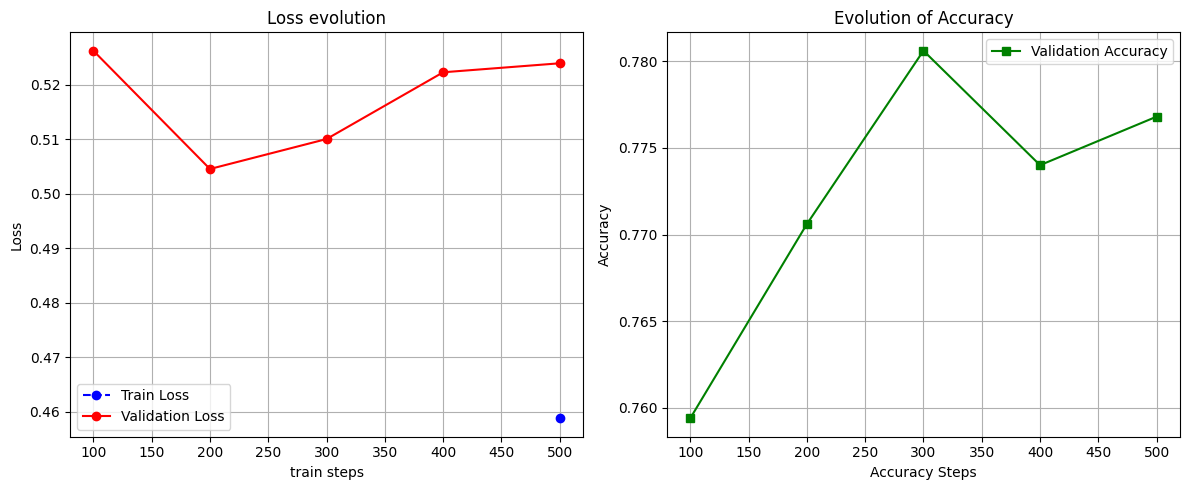

In [ ]:
# get history of model trained
history = trainer.state.log_history

# get training and validation for model trained
train_loss = [log["loss"] for log in history if "loss" in log and "eval_loss" not in log]
train_steps = [log["step"] for log in history if "loss" in log and "eval_loss" not in log]

eval_loss = [log["eval_loss"] for log in history if "eval_loss" in log]
eval_accuracy = [log["eval_accuracy"] for log in history if "eval_accuracy" in log]
eval_steps = [log["step"] for log in history if "eval_loss" in log]

# display Loss and accuracy graphe from model

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_steps, train_loss, label="Train Loss", color="blue", linestyle="--", marker="o")
plt.plot(eval_steps, eval_loss, label="Validation Loss", color="red", marker="o")
plt.title("Loss evolution")
plt.xlabel("train steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(eval_steps, eval_accuracy, label="Validation Accuracy", color="green", marker="s")
plt.title("Evolution of Accuracy")
plt.xlabel("Accuracy Steps")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

We see that the diagrams not display the Loss of train that is beacuse durong the train of model accuracy wasn't save in history of model, but we can show that our model has the best loss at the third step and the best accuracy at the fifth step. this result is exactly the save when we see the progression of model above.<br>
Now we are going to see the classification metrics to make conclusion.

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns

In [ ]:
print(classification_report(true_labels, predictions_labels))

              precision    recall  f1-score   support

           0       0.74      0.82      0.78      4982
           1       0.79      0.70      0.74      4906

    accuracy                           0.76      9888
   macro avg       0.76      0.76      0.76      9888
weighted avg       0.76      0.76      0.76      9888



we can see that, the f1-score is 76% that means that our model has the balanced score at 76% globaly.<br>
Let's show the confusion matrics to count the errors of models.

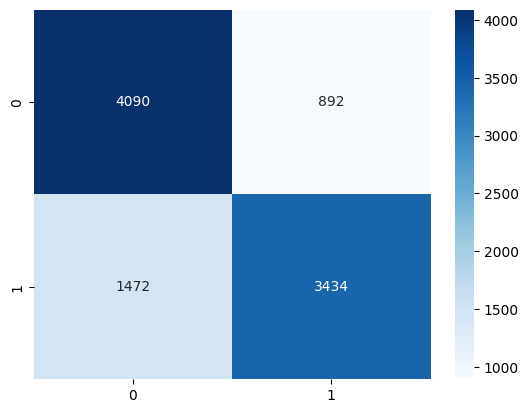

In [ ]:
sns.heatmap(confusion_matrix(true_labels, predictions_labels), annot=True, fmt='d', cmap='Blues')
plt.show()

On our confusion metrics diagram, we can see that the most predictions of model is for the negative class, that means that positive lable is lower than the negative label.<br>
The reason of this result is that :
- The negative label is greather than positive label before the split of data training
- The data that model uses for his train was random and little(5000 samples)

If we add data to train model the result can be must best than the current results, but our model is not bad for the production.<br>
we can alson see that our accuracy of our model is the same as the accuracy result than the 9888 validation samples above, that confirm that globali our model has 76% as accuracy on the data that it has never see.

We have not time to make the training of second model(flaubert model) to valid the best model, because the computer use the cpu to evaluate the model.<br>
This approch is other way to achive the goal of our work.<br>
Now we are going tho use the model in the application using streamlit.<br>
Thanks for your time to red this notebook.